## Intro to Deep Learning

### Project Topic

For my final project I trained a weather perdiction system using [Weather Type Classification](https://www.kaggle.com/datasets/nikhil7280/weather-type-classification/data) dataset provided by kaggle. I trained two deep learning models (MLP and CNN) to compare and see which model preformed the best for the weather prediction system.

### 1. Import necessary Python libraries

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

2025-04-23 20:22:22.990803: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-23 20:22:23.163706: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-23 20:22:23.226957: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-23 20:22:23.246649: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-23 20:22:23.358401: I tensorflow/core/platform/cpu_feature_guar

### 2. Check to see if Tensorflow is decting GPU 

In [2]:
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1745439745.635007   45582 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1745439745.875402   45582 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1745439745.875485   45582 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


### 3. Helper Functions

The following function loads a dataset from a CSV file by dynamically constructing the file path using the current working directory and a designated subdirectory named "dataset". It then uses pandas’ CSV reader to load the file’s contents into a DataFrame.

In [3]:
def load_data(file_name:str) -> pd.DataFrame:
    full_path = os.path.join(os.getcwd(), f"dataset/{file_name}")
    data = pd.read_csv(full_path)
    return data

The following function provide an inital overview of the dataset by displaing its structure, summary, statistics and preview of the first few records.

In [4]:
def data_info(data:pd.DataFrame):
    print(f"Dataset Size: {data.shape}\n")

    print("First 5 rows of dataset:")
    display(data.head())
    
    print("Summary of dataset:")
    display(data.describe())
    
    print("Sum of null values in dataset:")
    display(data.isnull().sum())

    print("Dataset info:")
    data.info()

The following function encodes categorical data before calculating and ploting the variance for the dataset columns.

In [5]:
def get_variance(data:pd.DataFrame):
    le = LabelEncoder()
    data["weather_type_encoded"] = le.fit_transform(data["Weather Type"])
    data_encoded = pd.get_dummies(data, columns=["Season", "Location", "Cloud Cover"], drop_first=True)
    data_encoded.drop(columns=["Weather Type"], inplace=True)
    var_series = data_encoded.var().sort_values()
    display(var_series)
    var_dict = var_series.to_dict()
    plt.figure(figsize=(10, 6))
    plt.bar(var_dict.keys(), var_dict.values())
    plt.xticks(rotation=45)
    plt.show()

The following function streamlines exploratory data analysis by automatically distinguishing between numeric and categorical features in the dataset and creating tailored visualizations for each. For numerical data, it generates histograms to highlight distributions, outliers, and central tendencies, while for categorical data, it produces bar charts to clearly depict the frequency counts of different category values.

In [6]:
def feature_hist_freq(data:pd.DataFrame):
    num_cols = data.select_dtypes(include=["number"]).columns
    cat_cols = data.select_dtypes(exclude=["number"]).columns

    total_plots = len(num_cols) + len(cat_cols)

    plt_cols = 3
    plt_rows = (total_plots // plt_cols) + int(total_plots % plt_cols)

    fig, axes = plt.subplots(plt_rows, plt_cols, figsize=(plt_cols * 9, plt_rows * 11))
    
    axes = axes.flatten()

    plt_index = 0

    for col in num_cols:
        ax = axes[plt_index]
        ax.hist(data[col], bins=15, edgecolor="black")
        ax.set_title(f"Histogram of {col}")
        plt_index += 1

    for col in cat_cols:
        ax = axes[plt_index]
        counts = data[col].value_counts()
        ax.bar(counts.index, counts.values, edgecolor="black")
        ax.set_title(f"Frequency for {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis='x', rotation=45)
        plt_index += 1

    for ax in axes[plt_index:]:
        fig.delaxes(ax)

The following function calculates the correlation matrix of the dataset and plots and sns heatmap of the correlation matrix.

In [7]:
def get_corr(data:pd.DataFrame):
    cleaned_data = data.drop(columns="Weather Type")
    num_feats = cleaned_data[["Temperature", "Humidity", "Wind Speed", "Precipitation (%)", "Atmospheric Pressure", "UV Index", "Visibility (km)"]]
    cat_feats = pd.get_dummies(cleaned_data[["Cloud Cover", "Season", "Location"]], prefix=["Cloud Cover", "Season", "Location"], drop_first=False)

    combo_df = pd.concat([num_feats, cat_feats], axis=1)
    corr_matrix = combo_df.corr()
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt="0.2f", linewidths=0.5)
    plt.title("Feature Correlation Heatmap")
    plt.show()

This follwing turns a pandas DataFrame into a ready-to-train tf.data.Dataset by: (1) slicing each row into a TensorFlow-friendly record, (2) optionally shuffling, (3) extracting the label column and encoding it via label_lookup, (4) stacking all specified numeric columns into one float tensor, (5) running each categorical column through its lookup layer and concatenating the results, and finally (6) batching and prefetching for efficient GPU/CPU utilization. The result is a dataset that yields tuples ({"numeric_input": …, "categorical_input": …}, y) on each iteration.

In [8]:
def df_to_dataset(
    dataframe,
    label,
    numeric_features,
    categorical_features,
    cat_lookups,
    label_lookup,
    shuffle=True,
    batch_size=32
):
    ds = tf.data.Dataset.from_tensor_slices(dict(dataframe))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))

    def pack_features(x):
        y_str = x.pop(label)

        num_feats = tf.stack([tf.cast(x[f], tf.float32) for f in numeric_features],axis=-1)

        cat_feats = tf.concat([cat_lookups[f](x[f]) for f in categorical_features],axis=-1)

        y = label_lookup(y_str)

        return ({"numeric_input": num_feats, "categorical_input": cat_feats},y)

    ds = ds.map(pack_features, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


The inner pack_features function takes a single-row feature dict, removes and encodes the raw label string into an integer, casts and stacks all specified numeric columns into one float32 tensor, applies each categorical lookup to its column and concatenates those one-hot encodings, then returns a tuple where the first element is a dict of the numeric and categorical tensors ("numeric_input", "categorical_input") and the second is the encoded label.

In [9]:
def to_sequential_inputs(features, label):
    normed_num = normalizer(features["numeric_input"])
    cat      = features["categorical_input"]
    combined = tf.concat([normed_num, cat], axis=-1)
    return combined, label

### 3. Load Data and Exploratory Data Analysis (EDA)

Load weather data by calling the load_data() function with the weather data filename. Then perfrom the inital data analysis by calling data_info() function. The data_info() function will print the out the data size, the first 5 rows in  the data set, a summary of some data metrics/statistics, check for any null values in the dataset, and finally display the dataset column info.

In [10]:
weather_data = load_data("weather_classification_data.csv")
data_info(weather_data)

Dataset Size: (13200, 11)

First 5 rows of dataset:


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


Summary of dataset:


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


Sum of null values in dataset:


Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


As part of the EDA call the get_variance() function that will display and plot the variance of every column in the dataset.

Cloud Cover_cloudy              0.030169
Season_Summer                   0.153159
Season_Spring                   0.158093
Cloud Cover_partly cloudy       0.226133
Location_mountain               0.231690
Location_inland                 0.231752
Season_Winter                   0.244394
Cloud Cover_overcast            0.248526
weather_type_encoded            1.250095
Visibility (km)                11.367005
UV Index                       14.873366
Wind Speed                     47.730193
Temperature                   302.284352
Humidity                      407.807656
Precipitation (%)            1020.581467
Atmospheric Pressure         1383.809399
dtype: float64

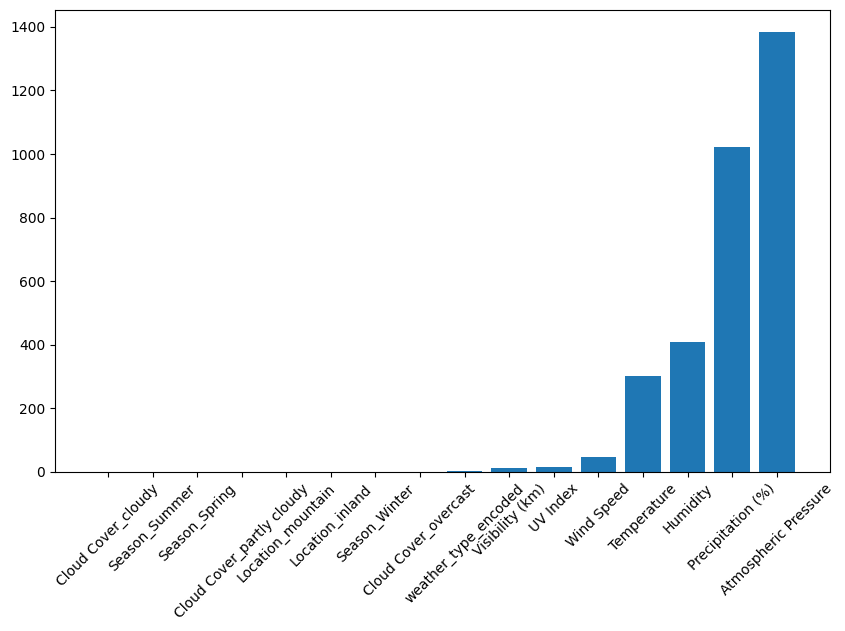

In [11]:
get_variance(weather_data)

Next plot the histogram and frequency of the features in the dataset by calling the feature_hist_freq() function. The plots visually allow for feature insights. For example the Atmospheric Pressure seems to be heavily skewed towards 1000 but since I am training a deep learning model it should not effect it much

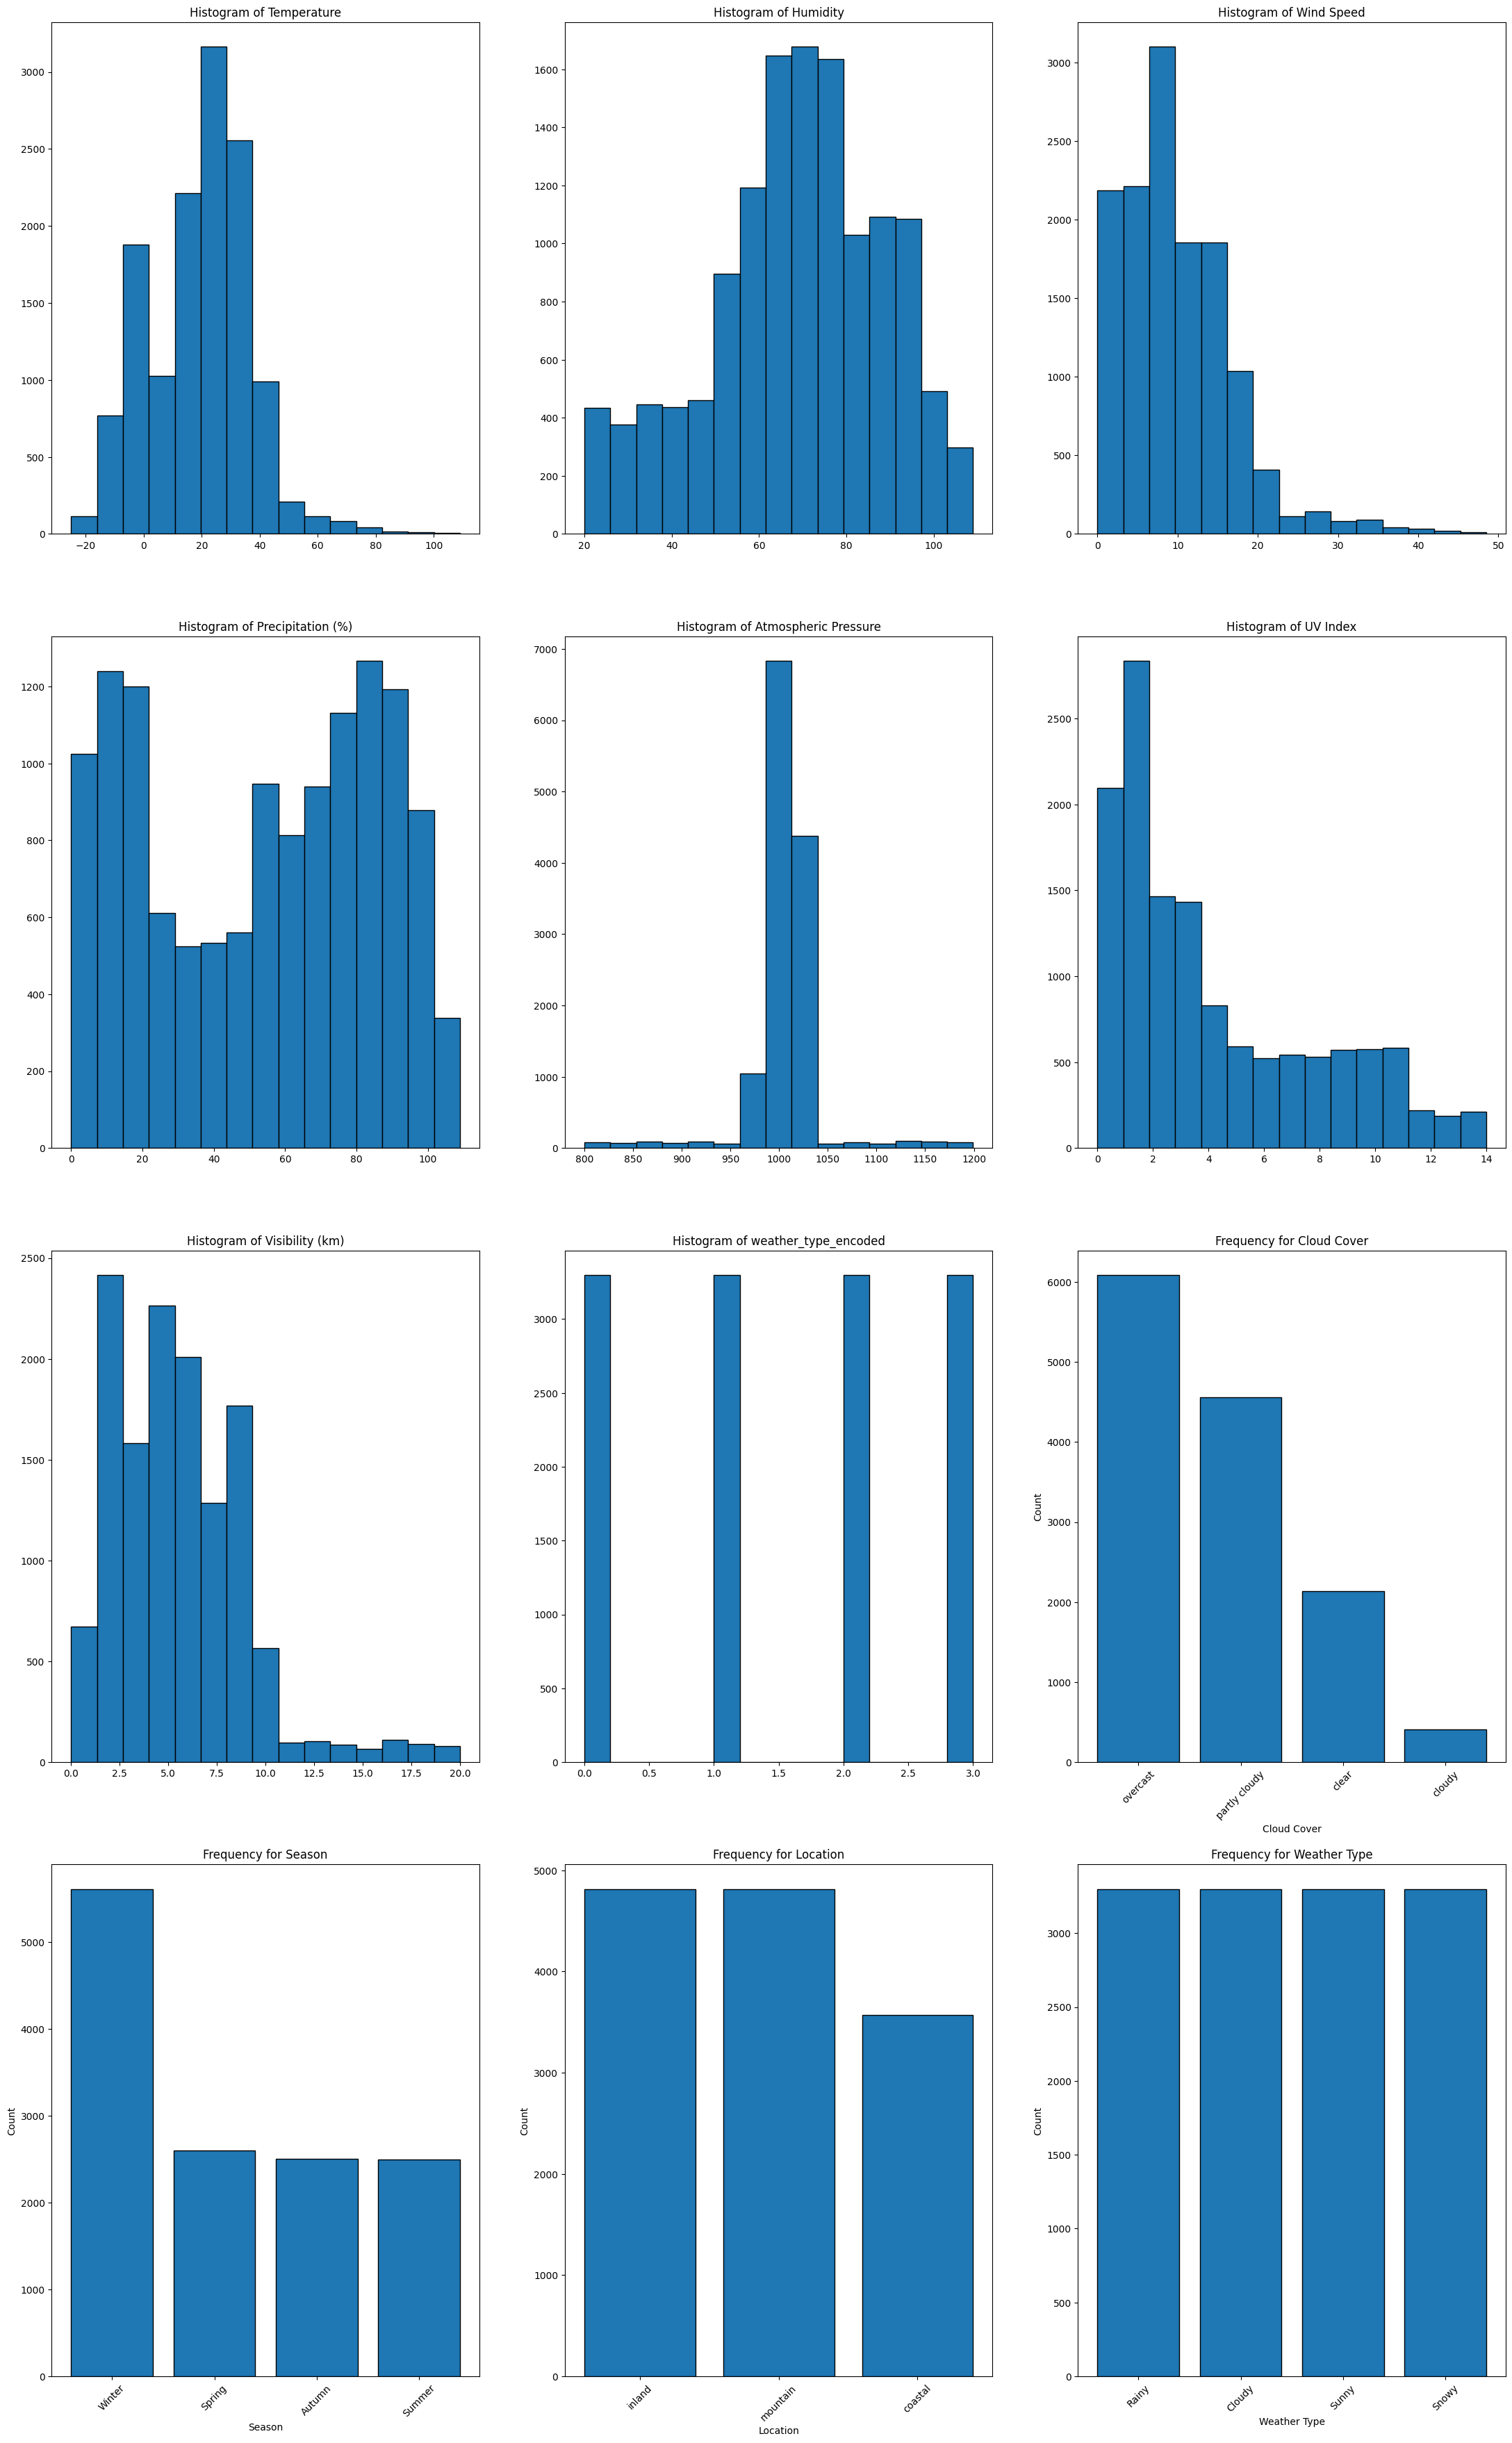

In [12]:
feats = feature_hist_freq(weather_data)

Next call get_corr() to get the corrlation of the current features in the dataset. 

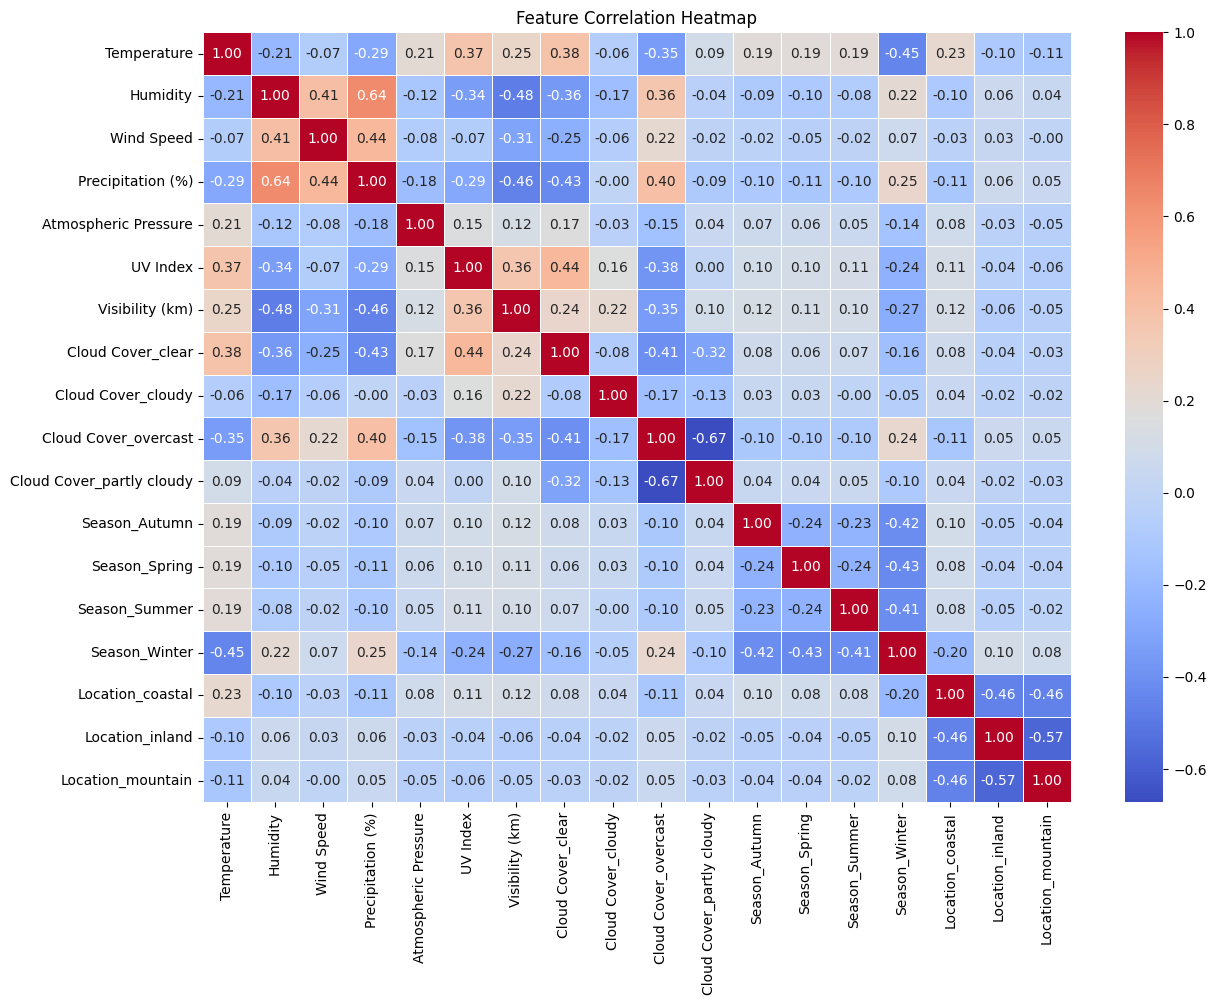

In [13]:
get_corr(weather_data)

### 4. Data Preprocessing

For data preprocessing I split the weather dataset into a subset of 80% training and 20% validataion set.

In [14]:
train_df, val_df = train_test_split(weather_data, test_size=0.2, stratify=weather_data["Weather Type"], random_state=42)

Create lists of numerical features and categorical featuers along with the label that is to be predicted.

In [15]:
numeric_feats = ["Temperature", "Humidity", "Wind Speed", "Precipitation (%)", "Atmospheric Pressure", "UV Index", "Visibility (km)"]
cat_feats = ["Cloud Cover", "Season","Location"]
label = "Weather Type"

Next create the "fits" for the each categorical layer by calling StringLookup() which will "one hot" encode the categorical features. Then call adapt() on each one to build the target label. Then, finally initilze a normalization layer for the numerical features. This prepates the data to be used with Keras layers. 

In [16]:
cat_lookups = {
    feat: tf.keras.layers.StringLookup(output_mode="one_hot")
    for feat in cat_feats
}

for feat, layer in cat_lookups.items():
    layer.adapt(train_df[feat])

label_lookup = tf.keras.layers.StringLookup(output_mode="int")
label_lookup.adapt(train_df[label])

normalizer = tf.keras.layers.Normalization()
normalizer.adapt(train_df[numeric_feats])

I0000 00:00:1745439747.404943   45582 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1745439747.405003   45582 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1745439747.405017   45582 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1745439747.541253   45582 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1745439747.541297   45582 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-23

Next the pandas dataframe subsets need to be converted to TensorFlow dataset objects to be used in model training

In [17]:
train_ds = df_to_dataset(train_df, label, numeric_feats, cat_feats, cat_lookups, label_lookup, shuffle=True, batch_size=32)
val_ds = df_to_dataset(val_df, label, numeric_feats, cat_feats, cat_lookups, label_lookup, shuffle=False, batch_size=32)

Next compute the combined_dim which is the total length of the flattend input vector. The the Tensorflow dataset objects are transformed to squential inputs to make it easier to build and train models.

In [18]:
combined_dim = len(numeric_feats) + sum(cat_lookups[f].vocabulary_size() for f in cat_feats)
seq_train_ds = train_ds.map(to_sequential_inputs, num_parallel_calls=tf.data.AUTOTUNE)
seq_val_ds   = val_ds.map(to_sequential_inputs, num_parallel_calls=tf.data.AUTOTUNE)

### 5. MLP Model Architecture

For my first model I decied to train a fully connected feed-forward network model since it would a fairly quick to train with a GPU. The architecture is as follows:

1. Inpute Layer:

    * Input shape is to the len of numeric features plus the sum the of the "one hot" encoded categorical features.
    * Dense set to 32 neurons with ReLU activation

2. Dense Layer:

    * 16 neurons with ReLU activation

3. Dense Layer:

    * 64 neurons with ReLU activation

4. Droput Layer:

    * Rate set to 40%

5. Dense Layer:

    * 32 neurons ReLu activation

6. Output Dense:

    * 5 number of classes with softmax activation


In [19]:
mlp_model = models.Sequential([
    layers.Input(shape=(combined_dim,), name="combined_input"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(32, activation="relu"),
    layers.Dense(label_lookup.vocabulary_size(), activation="softmax")
])

mlp_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

mlp_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                704       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 64)                1088      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 32)                2080      
                                                                 
 dense_4 (Dense)             (None, 5)                 165       
                                                                 
Total params: 4565 (17.83 KB)
Trainable params: 4565 (17

After creating the MLP model call the fit() method on it to perfrom the training on the model. The training will use the training subset and train over 20 epochs and use the validation subset as validation_data.

In [20]:
mlp_model_trained = mlp_model.fit(seq_train_ds, validation_data=seq_val_ds, epochs=20)

Epoch 1/20


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  1/330 [..............................] - ETA: 10:48 - loss: 1.6054 - accuracy: 0.2500

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

330/330 [==============================] - 3s 4ms/step - loss: 0.6419 - accuracy: 0.7670 - val_loss: 0.3215 - val_accuracy: 0.8837
Epoch 2/20
330/330 [==============================] - 1s 4ms/step - loss: 0.3030 - accuracy: 0.8874 - val_loss: 0.2647 - val_accuracy: 0.8913
Epoch 3/20
330/330 [==============================] - 1s 4ms/step - loss: 0.2533 - accuracy: 0.9013 - val_loss: 0.2318 - val_accuracy: 0.8977
Epoch 4/20
330/330 [==============================] - 1s 4ms/step - loss: 0.2314 - accuracy: 0.9041 - val_loss: 0.2245 - val_accuracy: 0.8996
Epoch 5/20
330/330 [==============================] - 1s 4ms/step - loss: 0.2218 - accuracy: 0.9050 - val_loss: 0.2215 - val_accuracy: 0.9008
Epoch 6/20
330/330 [==============================] - 1s 4ms/step - loss: 0.2100 - accuracy: 0.9077 - val_loss: 0.2110 - val_accuracy: 0.9034
Epoch 7/20
330/330 [==============================] - 1s 4ms/step - loss: 0.2065 - accuracy: 0.9085 - val_loss: 0.2133 - val_accuracy: 0.9027
Epoch 8/20
330/33

After training the model the next step is evaluate the performance of the trained model by using the test subset to score the accuracy of the model. The accuracy of the model resulted in an accuracy score of about 90.2%. Which is really good, however with some tuning some there might still be some room for improvement.

In [21]:
_, mlp_val_accuracy = mlp_model.evaluate(seq_val_ds)
print(f"Validation Accuracy: {mlp_val_accuracy:.2%}")


83/83 [==============================] - 0s 2ms/step - loss: 0.2007 - accuracy: 0.9019
Validation Accuracy: 90.19%


Next a plot of the training and validation accuracy over each epoch. This to aid in visualizing how the model learned over time. Based off the plot the model does have good generalization since the validation accuracy does rise with the training accuracy.

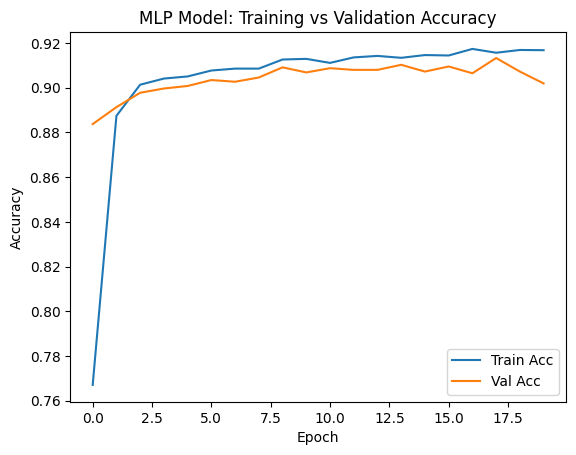

In [22]:
plt.plot(mlp_model_trained.history["accuracy"], label="Train Acc")
plt.plot(mlp_model_trained.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("MLP Model: Training vs Validation Accuracy")
plt.show()

### 6. MLP Model Architecture Tuning

In an effort to improve the accuracy of the model, some tuning will be attempted. The following hyperparameters were tuned in order to increase preformance.

* 1st dense layer was increased to 64 neurons
* 2nd dense layer was increased to 32 neurons
* 3rd dense layer was increased to 128 neurons
* 4th dense layer was increased to 64 neurons with softmax activation
* The learning rate was decreased to 5x10e^4
* Early stoping was implmented to halt once validation loss stops improving


In [23]:
mlp_model_tuned = models.Sequential([
    layers.Input(shape=(combined_dim,), name="combined_input"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dense(label_lookup.vocabulary_size(), activation="softmax")
])

opt = optimizers.Adam(learning_rate=5e-4)

mlp_model_tuned.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

mlp_model_tuned.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 64)                1408      
                                                                 
 dense_6 (Dense)             (None, 32)                2080      
                                                                 
 dense_7 (Dense)             (None, 128)               4224      
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_8 (Dense)             (None, 64)                8256      
                                                                 
 dense_9 (Dense)             (None, 5)                 325       
                                                                 
Total params: 16293 (63.64 KB)
Trainable params: 16293

Again after creating the tuned model call the fit() method on it to perfrom the training on the model. The training will use the training subset and train over 50 epochs and use the validation subset as validation_data.

In [24]:
mlp_model_tuned_trained = mlp_model_tuned.fit(seq_train_ds, validation_data=seq_val_ds, epochs=50, callbacks=[early_stop])

Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

 46/330 [===>..........................] - ETA: 0s - loss: 1.3132 - accuracy: 0.4891

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


330/330 [==============================] - 4s 4ms/step - loss: 0.6072 - accuracy: 0.7959 - val_loss: 0.3205 - val_accuracy: 0.8848
Epoch 2/50
330/330 [==============================] - 1s 4ms/step - loss: 0.2924 - accuracy: 0.8963 - val_loss: 0.2461 - val_accuracy: 0.9011
Epoch 3/50
330/330 [==============================] - 1s 4ms/step - loss: 0.2478 - accuracy: 0.9025 - val_loss: 0.2293 - val_accuracy: 0.8996
Epoch 4/50
330/330 [==============================] - 1s 4ms/step - loss: 0.2206 - accuracy: 0.9087 - val_loss: 0.2168 - val_accuracy: 0.9072
Epoch 5/50
330/330 [==============================] - 1s 4ms/step - loss: 0.2115 - accuracy: 0.9100 - val_loss: 0.2087 - val_accuracy: 0.9098
Epoch 6/50
330/330 [==============================] - 1s 4ms/step - loss: 0.2045 - accuracy: 0.9116 - val_loss: 0.2092 - val_accuracy: 0.9083
Epoch 7/50
330/330 [==============================] - 1s 4ms/step - loss: 0.1961 - accuracy: 0.9154 - val_loss: 0.2027 - val_accuracy: 0.9091
Epoch 8/50
330/33

After training the tuned model the next step is again evaluation of the performance of the tuned model by using the test subset to score the accuracy of the model. The accuracy of the tuned model resulted in an accuracy score of about 91.3%. Which is a slight improvment over the inital MLP model.

In [25]:
_, mlp_tuned_val_accuracy = mlp_model_tuned.evaluate(seq_val_ds)
print(f"Validation Accuracy: {mlp_tuned_val_accuracy:.2%}")

83/83 [==============================] - 0s 2ms/step - loss: 0.1927 - accuracy: 0.9133
Validation Accuracy: 91.33%


Next a plot of the training and validation accuracy over each epoch. This to aid in visualizing how the model learned over time. Based off the plot the model does have good generalization since the validation accuracy does rise with the training accuracy.

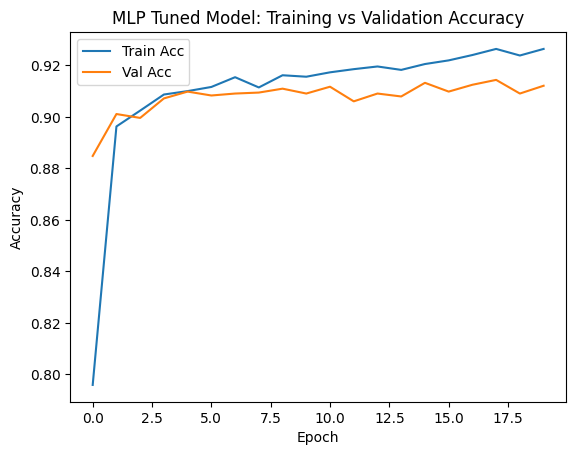

In [26]:
plt.plot(mlp_model_tuned_trained.history["accuracy"], label="Train Acc")
plt.plot(mlp_model_tuned_trained.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("MLP Tuned Model: Training vs Validation Accuracy")
plt.show()

### 

### 7. CNN Model Architecture

CNN models are also pretty easy to train and tune, so for the second model a CNN with following architecture was created:

1. Input Layer:

    * Input layer uses shape of combined_dim

2. Convolutional Layer 1:

    * 64 filters with kernel size of 3
    * padding set to "same"
    * Activation set to ReLu with 256 params
    * MaxPooling1D size is set to 2

3. Convolutional Layer 2:

    * 32 filters with kernal size of 3
    * padding set to "same"
    * Activation set to ReLu with 6176 params
    * GlobalAvergePooling1D flattens to sape (None, 32)

4. Dense Layer:

    * 32 neurons
    * ReLU activation with 1056 params
    * Drop rate set to 0.4

5. Output Layer:

    * 5 unit class with softmax activation
    * With 165 params 

In [27]:
cnn_model = models.Sequential([
    layers.Input(shape=(combined_dim,), name="combined_input"),
    layers.Reshape((combined_dim, 1)),

    layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(32, kernel_size=3, activation="relu", padding="same"),
    layers.GlobalAveragePooling1D(),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(label_lookup.vocabulary_size(), activation="softmax")
])

cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

cnn_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 21, 1)             0         
                                                                 
 conv1d (Conv1D)             (None, 21, 64)            256       
                                                                 
 max_pooling1d (MaxPooling1  (None, 10, 64)            0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 10, 32)            6176      
                                                                 
 global_average_pooling1d (  (None, 32)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense_10 (Dense)            (None, 32)               

Again after creating CNN model call the fit() method on it to perfrom the training on the model. The training will use the training subset and train over 30 epochs and use the validation subset as validation_data.

In [28]:
cnn_model_trained = cnn_model.fit(seq_train_ds, validation_data=seq_val_ds, epochs=30)

Epoch 1/30


W0000 00:00:1745439811.928375   45667 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439811.950491   45667 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439811.950611   45667 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439811.951361   45667 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439811.951695   45667 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439811.957894   45667 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439811.968099   45667 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439811.968415   45667 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439811.985544   45667 gp

 28/330 [=>............................] - ETA: 1s - loss: 1.5620 - accuracy: 0.2567

W0000 00:00:1745439812.357826   45664 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439812.357915   45664 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439812.357966   45664 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439812.358011   45664 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439812.358051   45664 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439812.358127   45664 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439812.358202   45664 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439812.358338   45664 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439812.358471   45664 gp

330/330 [==============================] - 5s 11ms/step - loss: 1.2392 - accuracy: 0.4698 - val_loss: 0.7476 - val_accuracy: 0.8091


...

330/330 [==============================] - 2s 5ms/step - loss: 0.5279 - accuracy: 0.8428 - val_loss: 0.3965 - val_accuracy: 0.8773
Epoch 4/30
 30/330 [=>............................] - ETA: 1s - loss: 0.4573 - accuracy: 0.8604

W0000 00:00:1745439818.923142   45663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439818.923257   45663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439818.923296   45663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439818.923338   45663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439818.923387   45663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439818.923436   45663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439818.923500   45663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439818.923602   45663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439818.923788   45663 gp

330/330 [==============================] - 2s 5ms/step - loss: 0.4453 - accuracy: 0.8577 - val_loss: 0.3501 - val_accuracy: 0.8822
Epoch 5/30
 42/330 [==>...........................] - ETA: 1s - loss: 0.4485 - accuracy: 0.8452

W0000 00:00:1745439820.453828   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439820.453917   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439820.453951   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439820.453996   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439820.454050   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439820.454106   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439820.454160   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439820.454246   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439820.454461   45669 gp

330/330 [==============================] - 2s 5ms/step - loss: 0.4002 - accuracy: 0.8649 - val_loss: 0.3149 - val_accuracy: 0.8848
Epoch 6/30
330/330 [==============================] - 2s 5ms/step - loss: 0.3709 - accuracy: 0.8679 - val_loss: 0.3051 - val_accuracy: 0.8833
Epoch 7/30
330/330 [==============================] - 2s 5ms/step - loss: 0.3477 - accuracy: 0.8739 - val_loss: 0.2908 - val_accuracy: 0.8894
Epoch 8/30
330/330 [==============================] - 2s 5ms/step - loss: 0.3394 - accuracy: 0.8753 - val_loss: 0.2829 - val_accuracy: 0.8875
Epoch 9/30
330/330 [==============================] - 2s 5ms/step - loss: 0.3275 - accuracy: 0.8783 - val_loss: 0.2877 - val_accuracy: 0.8830
Epoch 10/30
330/330 [==============================] - 2s 5ms/step - loss: 0.3150 - accuracy: 0.8749 - val_loss: 0.2672 - val_accuracy: 0.8913
Epoch 11/30
330/330 [==============================] - 1s 4ms/step - loss: 0.3062 - accuracy: 0.8818 - val_loss: 0.2587 - val_accuracy: 0.8958
Epoch 12/30
330

After training the CNN model the next step is again evaluation of the performance of the model by using the test subset to score the accuracy of the model. The accuracy of the CNN model resulted in an accuracy score of about 90.04%. Which is still really good, however it performed the worst so far out of the intial MLP model and tuned MLP model.

In [29]:
_, cnn_val_accuracy = cnn_model.evaluate(seq_val_ds)
print(f"Validation Accuracy: {cnn_val_accuracy:.2%}")

83/83 [==============================] - 0s 2ms/step - loss: 0.2273 - accuracy: 0.9004
Validation Accuracy: 90.04%


Next a plot of the training and validation accuracy over each epoch. This to aid in visualizing how the model learned over time. Based off the plot the model does have good generalization since the validation accuracy does rise with the training accuracy.

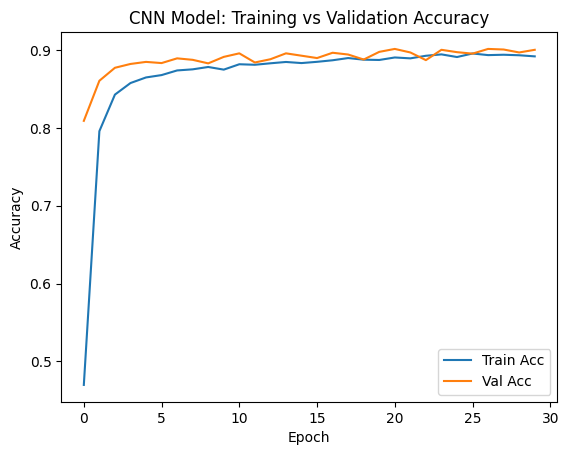

In [30]:
plt.plot(cnn_model_trained.history["accuracy"], label="Train Acc")
plt.plot(cnn_model_trained.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Model: Training vs Validation Accuracy")
plt.show()

### 8. CNN Model Architecture Tuning

In an effort to improve the accuracy of the model, some tuning will be attempted. The following hyperparameters were tuned in order to increase preformance.

* The 1st convolutional layer was increased from 64 filters to 128
* The 2nd convolutional  layers was increased from 32 filters to 64
* The pooling structure was chagned by adding an additional MaxPooling1D with a size of 2
* The 1st dense layer was increased from 32 neurons to 64
* The drop out rate was increased to 0.5.
* The learing rate was lowered to 3x10^-4
* Early stopping was implmented to halt once validation loss stops improving

In [31]:
cnn_model_tuned = models.Sequential([
    layers.Input(shape=(combined_dim,), name="combined_input"),
    layers.Reshape((combined_dim, 1)),

    layers.Conv1D(128, kernel_size=3, activation="relu", padding="same"),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    layers.MaxPooling1D(pool_size=2),

    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(label_lookup.vocabulary_size(), activation="softmax")
])

opt = optimizers.Adam(learning_rate=3e-4)
cnn_model_tuned.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

cnn_model_tuned.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_1 (Reshape)         (None, 21, 1)             0         
                                                                 
 conv1d_2 (Conv1D)           (None, 21, 128)           512       
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 10, 128)           0         
 g1D)                                                            
                                                                 
 conv1d_3 (Conv1D)           (None, 10, 64)            24640     
                                                                 
 max_pooling1d_2 (MaxPoolin  (None, 5, 64)             0         
 g1D)                                                            
                                                                 
 global_average_pooling1d_1  (None, 64)               

Again after creating tuned CNN model call the fit() method on it to perfrom the training on the model. The training will use the training subset and train over 30 epochs and use the validation subset as validation_data.

In [32]:
cnn_model_tuned_trained = cnn_model_tuned.fit(seq_train_ds, validation_data=seq_val_ds, epochs=30, callbacks=[early_stop])

Epoch 1/30


W0000 00:00:1745439863.352740   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.352851   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.352935   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.353020   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.353109   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.353348   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.353591   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.353737   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.353914   45669 gp

 27/330 [=>............................] - ETA: 1s - loss: 1.5836 - accuracy: 0.2894

W0000 00:00:1745439863.570994   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.571106   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.571188   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.571268   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.571431   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.571702   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.571807   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.572064   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439863.572323   45662 gp

330/330 [==============================] - ETA: 0s - loss: 1.2343 - accuracy: 0.5020

W0000 00:00:1745439865.036104   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.036261   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.036408   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.036545   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.036713   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.036884   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.037127   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.037332   45662 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.037682   45662 gp

330/330 [==============================] - 2s 5ms/step - loss: 1.2343 - accuracy: 0.5020 - val_loss: 0.7928 - val_accuracy: 0.8140
Epoch 2/30
 27/330 [=>............................] - ETA: 1s - loss: 0.8793 - accuracy: 0.7095

W0000 00:00:1745439865.236537   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.236658   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.236719   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.236783   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.236841   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.236908   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.236978   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.237041   45669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745439865.237139   45669 gp

330/330 [==============================] - 2s 5ms/step - loss: 0.7027 - accuracy: 0.7830 - val_loss: 0.5008 - val_accuracy: 0.8723
Epoch 3/30
330/330 [==============================] - 2s 5ms/step - loss: 0.5194 - accuracy: 0.8466 - val_loss: 0.4025 - val_accuracy: 0.8860
Epoch 4/30
330/330 [==============================] - 2s 5ms/step - loss: 0.4467 - accuracy: 0.8633 - val_loss: 0.3646 - val_accuracy: 0.8848
Epoch 5/30
330/330 [==============================] - 2s 5ms/step - loss: 0.4016 - accuracy: 0.8706 - val_loss: 0.3311 - val_accuracy: 0.8898
Epoch 6/30
330/330 [==============================] - 2s 5ms/step - loss: 0.3724 - accuracy: 0.8772 - val_loss: 0.3057 - val_accuracy: 0.8920
Epoch 7/30
330/330 [==============================] - 2s 5ms/step - loss: 0.3530 - accuracy: 0.8807 - val_loss: 0.2959 - val_accuracy: 0.8905
Epoch 8/30
330/330 [==============================] - 2s 5ms/step - loss: 0.3316 - accuracy: 0.8845 - val_loss: 0.2809 - val_accuracy: 0.8936
Epoch 9/30
330/33

After training the tuned CNN model the next step is again evaluation of the performance of the tuned model by using the test subset to score the accuracy of the model. The accuracy of the tuned model resulted in an accuracy score of about 91.14%. Which is slightly better than the inital CNN model but it is lower than the MLP models but not by much.

In [33]:
_, cnn_tuned_val_accuracy = cnn_model_tuned.evaluate(seq_val_ds)
print(f"Validation Accuracy: {cnn_tuned_val_accuracy:.2%}")

83/83 [==============================] - 0s 2ms/step - loss: 0.2038 - accuracy: 0.9114
Validation Accuracy: 91.14%


Next a plot of the training and validation accuracy over each epoch. This to aid in visualizing how the model learned over time. Based off the plot the model does have good generalization since the validation accuracy does rise with the training accuracy.

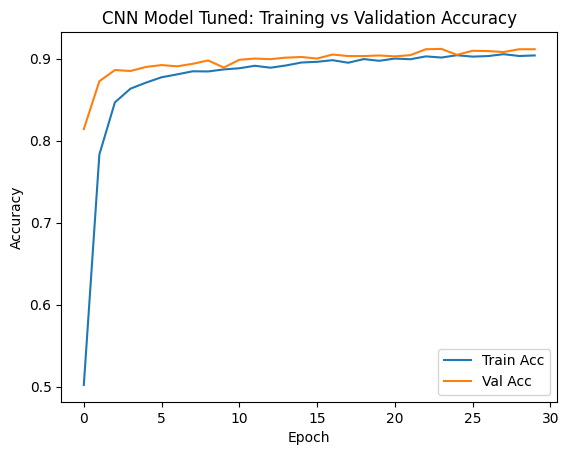

In [34]:
plt.plot(cnn_model_tuned_trained.history["accuracy"], label="Train Acc")
plt.plot(cnn_model_tuned_trained.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Model Tuned: Training vs Validation Accuracy")
plt.show()

In order to visually how well each model , a bar plot of all the model accuracies was created. The bar plots shows that the tuned MLP model preformed the best but not by much. In fact all the models scored accuracies that were relatively close to each other. Overall the tuned models scored slightly better.

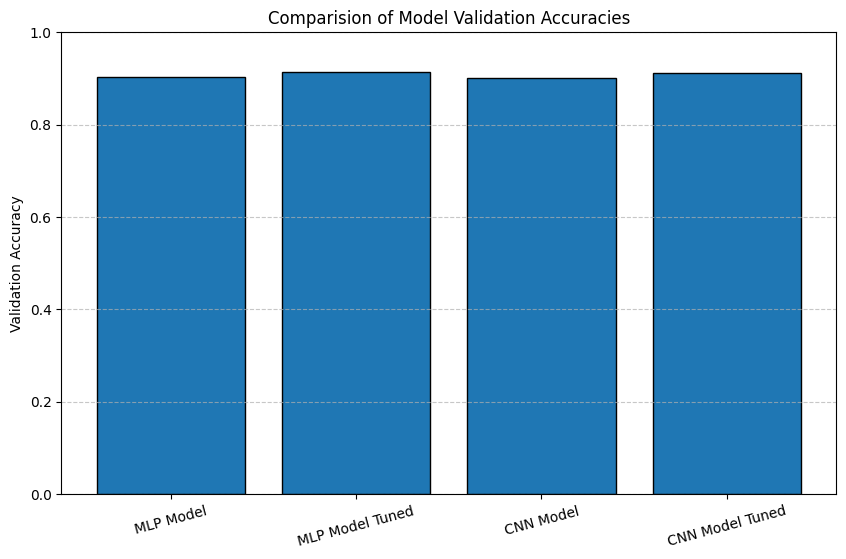

In [35]:
model_accs = [mlp_val_accuracy, mlp_tuned_val_accuracy, cnn_val_accuracy, cnn_tuned_val_accuracy]

model_names = ["MLP Model", "MLP Model Tuned", "CNN Model", "CNN Model Tuned"]

plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accs, edgecolor="black")
plt.ylim(0, 1)
plt.ylabel("Validation Accuracy")
plt.title("Comparision of Model Validation Accuracies")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=15)
plt.show()

### Conclusion

All of the models—ranging from the initial MLP and CNN baselines to their tuned variants—achieved strong performance, each surpassing 90% validation accuracy on the weather classification task. The tuned MLP edged out the competition, improving upon the baseline by under 2% yet still securing the highest accuracy overall. The initial CNN lagged behind, indicating that its inductive bias toward local patterns was less well-suited for this particular tabular dataset. These results suggest that while careful hyperparameter tuning can yield modest gains, the core choice of architecture (in this case, a straightforward feed-forward network) remains the dominant factor in model effectiveness. In the future, to push performance even higher, exploration into richer feature engineering (interaction terms or polynomial expansion) more extensive hyperparameter searches, ensemble methods that combine MLPs, CNNs or other deep learning algorithms. 

### Refrences

1. [Tensorflow Docs](https://www.tensorflow.org/api_docs/python/tf/all_symbols)
2. [Keras API Docs](https://keras.io/api/)
3. [Tensorflow CNN Tutorial](https://www.tensorflow.org/tutorials/images/cnn)
4. [MLP in Tensorflow](https://www.geeksforgeeks.org/multi-layer-perceptron-learning-in-tensorflow/)
5. [Video tutorial Setting up TensorFlow with GPU Support](https://youtu.be/Opi8zwJZ_8I?si=Fy9Fl32sWJGw6IsU)


### Github Repo

https://github.com/charliearvizu-edu/CSCA_5642_FINAL_PROJ/tree/dev